In [12]:
"""
Copy-paste single-file script.

What this version adds vs your original:
1) Bulk WLS with *random absorption path length* (Beer–Lambert):
   - In any volume with wls=True and mu_a(λ)>0, we sample s_abs = -ln(U)/mu_a(λ)
   - If s_abs happens before the next boundary, we absorb there and (with QY) re-emit
2) Optional dichroic “mirror slab” behavior:
   - At interfaces into/out of the DM volume, apply wavelength-dependent reflect/transmit
   - Reflection is specular about the boundary normal; transmission continues forward
   - (You can switch this off by setting dm_is_dichroic=False)

Time-of-flight is intentionally omitted; compute later from the saved trajectory + n(λ).
"""

import numpy as np
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import matplotlib.pyplot as plt


In [13]:
# -----------------------------
# Optics helpers
# -----------------------------

C0 = 299_792_458.0

def random_isotropic_direction(rng):
    u = rng.uniform(-1.0, 1.0)
    phi = rng.uniform(0.0, 2.0*np.pi)
    s = np.sqrt(max(0.0, 1.0 - u*u))
    return np.array([s*np.cos(phi), s*np.sin(phi), u], dtype=float)

def reflect(direction, normal):
    d = direction / np.linalg.norm(direction)
    n = normal / np.linalg.norm(normal)
    r = d - 2.0*np.dot(d, n)*n
    return r / np.linalg.norm(r)

def refract(direction, normal, n1, n2):
    d = direction / np.linalg.norm(direction)
    n = normal / np.linalg.norm(normal)

    cos_i = -np.dot(n, d)
    sin2_i = max(0.0, 1.0 - cos_i*cos_i)
    eta = n1 / n2
    sin2_t = eta*eta * sin2_i

    if sin2_t >= 1.0:
        return None  # TIR

    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    t = eta*d + (eta*cos_i - cos_t)*n
    return t / np.linalg.norm(t)

In [14]:
# -----------------------------
# Geometry: AABB cuboid
# -----------------------------

class Cuboid:
    """
    Axis-aligned cuboid. Optional physics:
      - wls: Beer–Lambert absorption in volume, with re-emission
      - mu_a: absorption coefficient [1/m] vs wavelength (dict/callable/scalar)
      - quantum_yield: re-emission probability after absorption
      - emission: either transitions dict (nearest key) or gaussian peak/sigma
      - is_dichroic: if True, apply reflectance/transmittance at interfaces
      - reflectance: dict/callable/scalar returning R(λ) in [0,1]
        (T is assumed 1-R; you can also set transmittance similarly if you want)
    """
    def __init__(
        self,
        vertices,
        refractive_index=None,
        name=None,
        wls=False,
        mu_a=0.0,
        quantum_yield=1.0,
        wls_transitions=None,
        emission_peak_nm=None,
        emission_sigma_nm=None,
        is_dichroic=False,
        reflectance=0.0,
    ):
        self.vertices = np.array(vertices, dtype=float)
        self.min_vertex = np.min(self.vertices, axis=0)
        self.max_vertex = np.max(self.vertices, axis=0)

        self.refractive_index = refractive_index if refractive_index is not None else {400.0: 1.0}
        self.name = name

        self.wls = bool(wls)
        self.mu_a = mu_a
        self.quantum_yield = float(quantum_yield)
        self.wls_transitions = wls_transitions or {}
        self.emission_peak_nm = emission_peak_nm
        self.emission_sigma_nm = emission_sigma_nm

        self.is_dichroic = bool(is_dichroic)
        self.reflectance = reflectance

    def contains(self, point, eps=1e-12):
        p = np.asarray(point, float)
        return np.all(p >= self.min_vertex - eps) and np.all(p <= self.max_vertex + eps)

    def intersect_distance(self, origin, direction):
        """
        Ray-AABB intersection distance to first hit (>=0). Returns inf if no hit.
        """
        o = np.asarray(origin, float)
        d = np.asarray(direction, float)

        inv = np.where(np.abs(d) > 0, 1.0 / d, np.inf)
        t0 = (self.min_vertex - o) * inv
        t1 = (self.max_vertex - o) * inv

        tmin = np.max(np.minimum(t0, t1))
        tmax = np.min(np.maximum(t0, t1))
        if tmax < 0 or tmin > tmax:
            return np.inf
        return tmin if tmin >= 0 else tmax

    def surface_normal_at(self, point, eps=1e-9):
        p = np.asarray(point, float)
        if abs(p[0] - self.min_vertex[0]) < eps: return np.array([-1.0, 0.0, 0.0])
        if abs(p[0] - self.max_vertex[0]) < eps: return np.array([+1.0, 0.0, 0.0])
        if abs(p[1] - self.min_vertex[1]) < eps: return np.array([0.0, -1.0, 0.0])
        if abs(p[1] - self.max_vertex[1]) < eps: return np.array([0.0, +1.0, 0.0])
        if abs(p[2] - self.min_vertex[2]) < eps: return np.array([0.0, 0.0, -1.0])
        if abs(p[2] - self.max_vertex[2]) < eps: return np.array([0.0, 0.0, +1.0])

        # fallback
        dmins = np.abs(p - self.min_vertex)
        dmaxs = np.abs(self.max_vertex - p)
        candidates = np.concatenate([dmins, dmaxs])
        k = int(np.argmin(candidates))
        return [
            np.array([-1.0,0,0]), np.array([0,-1.0,0]), np.array([0,0,-1.0]),
            np.array([+1.0,0,0]), np.array([0,+1.0,0]), np.array([0,0,+1.0]),
        ][k]

    def get_refractive_index(self, wavelength_nm):
        if isinstance(self.refractive_index, dict):
            keys = np.array(list(self.refractive_index.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.refractive_index[float(keys[idx])])
        if callable(self.refractive_index):
            return float(self.refractive_index(wavelength_nm))
        return float(self.refractive_index)

    def get_mu_a(self, wavelength_nm):
        if isinstance(self.mu_a, dict):
            keys = np.array(list(self.mu_a.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.mu_a[float(keys[idx])])
        if callable(self.mu_a):
            return float(self.mu_a(wavelength_nm))
        return float(self.mu_a)

    def get_reflectance(self, wavelength_nm):
        if isinstance(self.reflectance, dict):
            keys = np.array(list(self.reflectance.keys()), dtype=float)
            idx = int(np.abs(keys - wavelength_nm).argmin())
            return float(self.reflectance[float(keys[idx])])
        if callable(self.reflectance):
            return float(self.reflectance(wavelength_nm))
        return float(self.reflectance)

    def sample_emission_wavelength(self, rng, in_lambda_nm):
        # 1) transitions dict (nearest key)
        if self.wls_transitions:
            keys = np.array(list(self.wls_transitions.keys()), dtype=float)
            idx = int(np.abs(keys - in_lambda_nm).argmin())
            return float(self.wls_transitions[float(keys[idx])])
        # 2) gaussian peak/sigma
        if self.emission_peak_nm is not None:
            sigma = float(self.emission_sigma_nm) if self.emission_sigma_nm is not None else 10.0
            out = rng.normal(loc=float(self.emission_peak_nm), scale=sigma)
            return float(max(1.0, out))
        # 3) no shift
        return float(in_lambda_nm)

    def which_face(self, point, eps=1e-9):
        p = np.asarray(point, float)
        if abs(p[0] - self.min_vertex[0]) < eps: return "xmin"
        if abs(p[0] - self.max_vertex[0]) < eps: return "xmax"
        if abs(p[1] - self.min_vertex[1]) < eps: return "ymin"
        if abs(p[1] - self.max_vertex[1]) < eps: return "ymax"
        if abs(p[2] - self.min_vertex[2]) < eps: return "zmin"
        if abs(p[2] - self.max_vertex[2]) < eps: return "zmax"
        return None

In [15]:
# -----------------------------
# Simulation
# -----------------------------

class PhotonSimulation:
    def __init__(
        self,
        volumes=None,
        source_position=None,
        sensor_positions=None,
        sensor_radius=0.0,
        num_photons=1000,
        max_thrown=10000,
        max_workers=8,
        initial_wavelength_nm=128.0,
        max_steps=5000,
        rng_seed=None,
    ):
        self.volumes = volumes[:] if volumes else []
        self.source_position = np.array(source_position, dtype=float) if source_position is not None else None
        self.sensor_positions = np.array(sensor_positions, dtype=float) if sensor_positions is not None else None
        self.sensor_radius = float(sensor_radius)

        self.num_photons = int(num_photons)
        self.max_thrown = int(max_thrown)
        self.max_workers = int(max_workers)
        self.initial_wavelength_nm = float(initial_wavelength_nm)
        self.max_steps = int(max_steps)
        self.rng_seed = rng_seed

        self.data = []
        self.data_df = None

        if self.volumes:
            all_vertices = np.vstack([v.vertices for v in self.volumes])
            self.combined_region = Cuboid(all_vertices, name="combined")
        else:
            self.combined_region = None

    def find_containing_volume(self, point):
        for idx, v in enumerate(self.volumes):
            if v.contains(point):
                return idx, v
        return None, None

    def hits_any_sensor(self, point):
        if self.sensor_positions is None or len(self.sensor_positions) == 0:
            return False
        p = np.asarray(point, float)
        d = np.linalg.norm(self.sensor_positions - p[None, :], axis=1)
        return bool(np.any(d <= self.sensor_radius))

    def serialize_trajectory(self, trajectory):
        return ";".join([",".join(map(str, p)) for p in trajectory])

    def propagate_single_photon(self, photon_index=0):
        seed = None if self.rng_seed is None else (self.rng_seed + 1_000_003 * photon_index)
        rng = np.random.default_rng(seed)

        direction = random_isotropic_direction(rng)
        position = self.source_position.copy()

        wavelength = self.initial_wavelength_nm
        wavelength_history = [wavelength]

        trajectory = [position.tolist()]
        reflections = 0
        path_length = 0.0

        idx, current = self.find_containing_volume(position)
        if current is None:
            return trajectory, "lost_outside", reflections, path_length, wavelength_history

        eps = 1e-9

        for _ in range(self.max_steps):
            if self.combined_region is not None and not self.combined_region.contains(position):
                return trajectory, f"lost_{current.name or idx}", reflections, path_length, wavelength_history

            # distance to current boundary
            t_boundary = current.intersect_distance(position, direction)
            if not np.isfinite(t_boundary) or t_boundary == np.inf:
                return trajectory, f"lost_{current.name or idx}", reflections, path_length, wavelength_history

            # ----- BULK WLS absorption competition -----
            # Sample absorption distance in current medium; if it happens before boundary,
            # absorb at that interior point and re-emit.
            if current.wls:
                mu = max(0.0, current.get_mu_a(wavelength))  # [1/m]
                if mu > 0.0:
                    U = max(rng.uniform(0.0, 1.0), 1e-300)
                    s_abs = -np.log(U) / mu

                    if s_abs < t_boundary:
                        # absorb in bulk before boundary
                        new_pos = position + direction * s_abs
                        trajectory.append(new_pos.tolist())
                        path_length += float(np.linalg.norm(new_pos - position))
                        position = new_pos

                        # non-radiative loss vs re-emission
                        if rng.uniform(0.0, 1.0) > current.quantum_yield:
                            return trajectory, f"absorbed_nonrad_{current.name or idx}", reflections, path_length, wavelength_history

                        # re-emit
                        wavelength = current.sample_emission_wavelength(rng, wavelength)
                        wavelength_history.append(wavelength)
                        direction = random_isotropic_direction(rng)

                        # optional: immediate sensor hit (rare)
                        if self.hits_any_sensor(position):
                            return trajectory, "arrived", reflections, path_length, wavelength_history

                        # stay in same volume after re-emission
                        continue

            # otherwise propagate to boundary
            boundary_pos = position + direction * t_boundary
            trajectory.append(boundary_pos.tolist())
            path_length += float(np.linalg.norm(boundary_pos - position))
            position = boundary_pos

            # sensor hit test at boundary point
            if self.hits_any_sensor(position):
                return trajectory, "arrived", reflections, path_length, wavelength_history

            # Determine next volume by nudging forward
            ahead = position + direction * eps
            next_idx, next_vol = self.find_containing_volume(ahead)

            if next_vol is None:
                return trajectory, f"lost_{current.name or idx}", reflections, path_length, wavelength_history

            n_face = current.surface_normal_at(position)

            # ----- Dichroic behavior (optional) -----
            # If current or next volume is dichroic, apply wavelength-dependent reflectance at interface.
            if current.is_dichroic or next_vol.is_dichroic:
                # choose which reflectance curve to use (prefer the DM volume's setting)
                dm_vol = current if current.is_dichroic else next_vol
                R = np.clip(dm_vol.get_reflectance(wavelength), 0.0, 1.0)
                if rng.uniform(0.0, 1.0) < R:
                    direction = reflect(direction, n_face)
                    reflections += 1
                    position = position + direction * eps
                    continue
                # else transmit: fall through to refraction handling below

            # ----- Regular refraction / TIR at interface -----
            if next_idx == idx:
                # reflection on same volume boundary
                direction = reflect(direction, n_face)
                reflections += 1
                position = position + direction * eps
                continue

            n1 = current.get_refractive_index(wavelength)
            n2 = next_vol.get_refractive_index(wavelength)

            new_dir = refract(direction, n_face, n1, n2)
            if new_dir is None:
                direction = reflect(direction, n_face)
                reflections += 1
                position = position + direction * eps
                continue

            direction = new_dir
            idx, current = next_idx, next_vol
            position = position + direction * eps

        return trajectory, f"lost_maxsteps_{current.name or idx}", reflections, path_length, wavelength_history

    def propagate_photons(self):
        start = time.time()
        self.data = []

        successful = 0
        thrown = 0

        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            futures = {executor.submit(self.propagate_single_photon, i): i for i in range(self.max_thrown)}
            with tqdm(total=self.max_thrown, desc="Overall Progress", position=0, leave=True) as pbar:
                for fut in as_completed(futures):
                    thrown += 1
                    traj, status, refl, plen, wl_hist = fut.result()
                    pbar.update(1)

                    self.data.append({
                        "trajectory": self.serialize_trajectory(traj),
                        "event_type": status,
                        "arrived": status == "arrived",
                        "lost": status != "arrived",
                        "n_reflections": refl,
                        "path_length": plen,
                        "wavelength_history": ";".join(map(lambda x: f"{x:.6g}", wl_hist)),
                    })

                    if status == "arrived":
                        successful += 1
                        if successful >= self.num_photons:
                            break

                    if thrown >= self.max_thrown:
                        break

        self.data_df = pd.DataFrame(self.data)
        elapsed = time.time() - start

        print(f"Total photons thrown: {thrown}")
        print(f"Successful photons: {int(self.data_df['arrived'].sum())}")
        print(f"Elapsed time: {elapsed:.3f} s")

        for v in self.volumes:
            name = v.name or self.volumes.index(v)
            key = f"lost_{name}"
            n_lost = int((self.data_df["event_type"] == key).sum())
            if n_lost:
                print(f"Lost in {name}: {n_lost}")

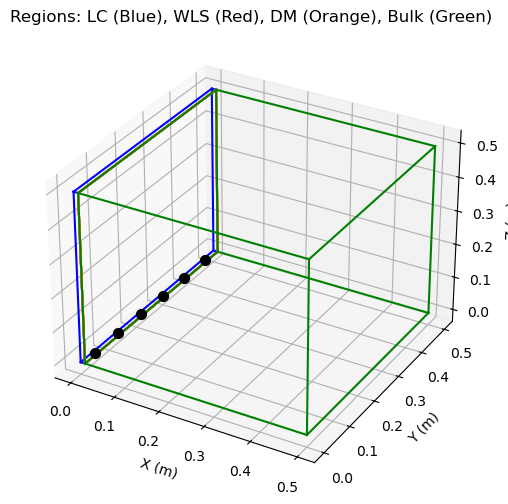

In [16]:
# =========================================================
# YOUR SETUP (directly integrated)
# =========================================================

# define config inputs
width = 0.5  # meters
height = 0.5  # meters
# bulk
bulk_x = 0.5
bulk_y = height
bulk_z = width
# wls
wls_x = 3e-6
wls_y = height
wls_z = width
# dichroic mirror
dm_x = 112e-6
dm_y = height
dm_z = width
# lc
lc_x = 1e-2
lc_y = height
lc_z = width

# sensors
n_sipms = 6
sensor_positions = [[lc_x/2.0, (1 + 2 * i) / (2 * n_sipms) * height, 0.0] for i in range(n_sipms)]

# Light collection region (LC)
lc_region_vertices = [
    [0, 0, 0], [lc_x, 0, 0],
    [lc_x, lc_y, 0], [0, lc_y, 0],
    [0, 0, lc_z], [lc_x, 0, lc_z],
    [lc_x, lc_y, lc_z], [0, lc_y, lc_z]
]

# Wavelength shifter region (WLS), sits after LC along x-axis
wls_region_vertices = [
    [lc_x, 0, 0], [lc_x + wls_x, 0, 0],
    [lc_x + wls_x, wls_y, 0], [lc_x, wls_y, 0],
    [lc_x, 0, wls_z], [lc_x + wls_x, 0, wls_z],
    [lc_x + wls_x, wls_y, wls_z], [lc_x, wls_y, wls_z]
]

# Dichroic mirror region (DM), sits after WLS along x-axis
dm_region_vertices = [
    [lc_x + wls_x, 0, 0], [lc_x + wls_x + dm_x, 0, 0],
    [lc_x + wls_x + dm_x, dm_y, 0], [lc_x + wls_x, dm_y, 0],
    [lc_x + wls_x, 0, dm_z], [lc_x + wls_x + dm_x, 0, dm_z],
    [lc_x + wls_x + dm_x, dm_y, dm_z], [lc_x + wls_x, dm_y, dm_z]
]

# Bulk region, sits after DM along x-axis
bulk_region_vertices = [
    [lc_x + wls_x + dm_x, 0, 0], [bulk_x, 0, 0],
    [bulk_x, bulk_y, 0], [lc_x + wls_x + dm_x, bulk_y, 0],
    [lc_x + wls_x + dm_x, 0, bulk_z], [bulk_x, 0, bulk_z],
    [bulk_x, bulk_y, bulk_z], [lc_x + wls_x + dm_x, bulk_y, bulk_z]
]

# Visualisation of the regions
plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

def draw_box(vertices, color):
    V = np.array(vertices, dtype=float)
    edges = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]
    for a,b in edges:
        ax.plot([V[a,0],V[b,0]],[V[a,1],V[b,1]],[V[a,2],V[b,2]], color=color)

draw_box(lc_region_vertices, "blue")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title("Regions: LC (Blue), WLS (Red), DM (Orange), Bulk (Green)")
plt.show()

In [17]:
# =========================================================
# Physics knobs (EDIT THESE!)
# =========================================================

# --- EJ280 (LC) absorption coefficient mu_a [1/m] vs wavelength.
# You *must* tune these. If you set mu_a too small, almost no absorption->reemission.
# If too big, everything shifts immediately.
mu_a_lc = {
    128.0: 0.0,     # EJ280 typically not absorbing VUV if it doesn't see it; set as you like
    420.0: 20.0,    # example: absorption length 5 cm
    490.0: 0.2,     # example: mostly transparent at its own emission
}

# EJ280 emission ~490 nm (example)
lc_qy = 0.95

# --- TPB (WLS slab) absorption coefficient mu_a [1/m] vs wavelength.
# For a 3 µm film, mu_a can be enormous in VUV; treat these as placeholders.
mu_a_tpb = {
    128.0: 5e5,     # example: absorption length 2 microns
    420.0: 10.0,    # TPB mostly transparent in blue
    490.0: 1.0,
}
tpb_qy = 0.9

# --- Dichroic: reflectance vs wavelength (placeholders).
# For example: reflect blue (420) strongly, transmit green (490) mostly.
# You can invert this depending on your design.
dm_is_dichroic = True
dm_reflectance = {
    128.0: 0.2,
    420.0: 0.95,
    490.0: 0.10,
}

In [27]:
# =========================================================
# Define volumes (as Cuboid objects)
# =========================================================

lc = Cuboid(
    vertices=lc_region_vertices,
    refractive_index={128: 1.65, 420: 1.60, 490: 1.58},
    name="lc",
    wls=True,                          # EJ280 as bulk WLS
    mu_a=mu_a_lc,
    quantum_yield=lc_qy,
    emission_peak_nm=490.0,
    emission_sigma_nm=20.0,
)
lc.boundary_mode = {
    "ymin": "reflect",
    "ymax": "reflect",
    "zmin": "reflect",
    "zmax": "reflect",
    "xmin": "reflect",   # sensor side maybe?
    "xmax": "escape",
}
lc.reflectivity = {
    "ymin": 0.98,
    "ymax": 0.98,
    "zmin": 0.98,
    "zmax": 0.98,
    "xmin": 0.98,
}

wls = Cuboid(
    vertices=wls_region_vertices,
    refractive_index={128: 1.70, 420: 1.62, 490: 1.60},
    name="wls",
    wls=True,                          # TPB slab as bulk WLS
    mu_a=mu_a_tpb,
    quantum_yield=tpb_qy,
    emission_peak_nm=420.0,
    emission_sigma_nm=15.0,
)
wls.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

dm = Cuboid(
    vertices=dm_region_vertices,
    refractive_index={128: 1.5, 420: 1.65, 490: 1.9},
    name="dm",
    wls=False,
    is_dichroic=dm_is_dichroic,
    reflectance=dm_reflectance,
)
dm.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

bulk = Cuboid(
    vertices=bulk_region_vertices,
    refractive_index={128: 1.6, 420: 1.23, 490: 1.22},
    name="bulk",
    wls=False,
)
bulk.boundary_mode = {
    "ymin": "escape",
    "ymax": "escape",
    "zmin": "escape",
    "zmax": "escape",
    "xmin": "escape",   # sensor side maybe?
    "xmax": "escape",
}

volumes = [lc, wls, dm, bulk]

In [28]:
# =========================================================
# Run simulation
# =========================================================

simulation = PhotonSimulation(
    volumes=volumes,
    source_position=[0.25, 0.25, 0.25],
    sensor_positions=sensor_positions,
    sensor_radius=0.01,
    num_photons=10000,
    max_thrown=100000,
    max_workers=8,
    initial_wavelength_nm=128.0,   # LAr scintillation example
    max_steps=5000,
    rng_seed=12345,
)

simulation.propagate_photons()

# DataFrame available as:
df = simulation.data_df
print(df.head())

Overall Progress: 100%|██████████| 100000/100000 [00:05<00:00, 19447.09it/s]


Total photons thrown: 100000
Successful photons: 42
Elapsed time: 13.762 s
Lost in dm: 14004
Lost in bulk: 85954
                                          trajectory event_type  arrived  \
0  0.25,0.25,0.25;0.42304097928302353,0.254723951...  lost_bulk    False   
1  0.25,0.25,0.25;0.010114999999999985,0.01625018...    lost_dm    False   
2  0.25,0.25,0.25;0.010114999999999985,0.22116083...  lost_bulk    False   
3  0.25,0.25,0.25;0.19167034586210266,0.042005689...  lost_bulk    False   
4  0.25,0.25,0.25;0.33593275455877425,0.391105736...  lost_bulk    False   

   lost  n_reflections  path_length wavelength_history  
0  True              0     0.304081                128  
1  True              0     0.335209                128  
2  True              1     0.736642                128  
3  True              0     0.330400                128  
4  True              0     0.299659                128  


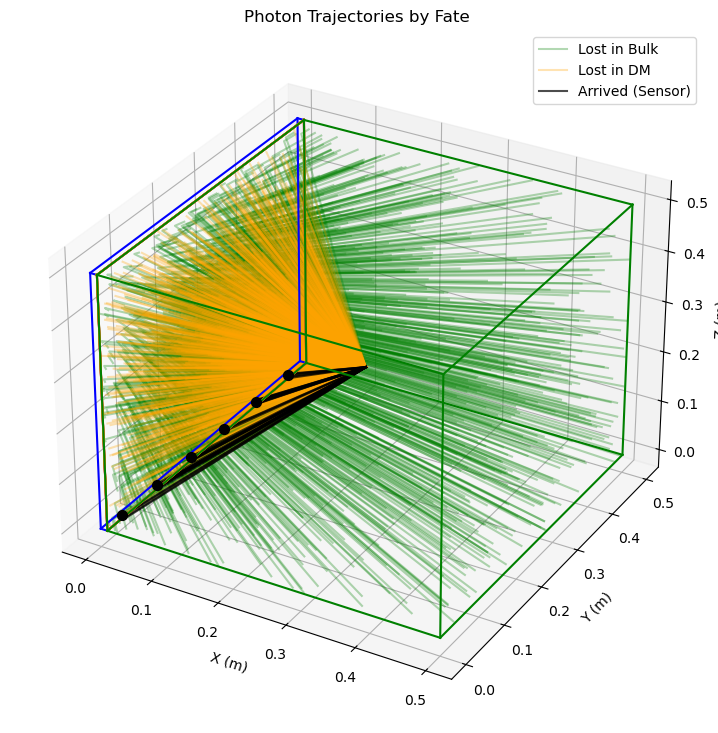

In [45]:
# Plot trajectories by event type: lost_bulk, lost_dm, lost_wls, lost_lc, arrived

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

# Helper for plotting
def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=1000):
    for i, traj_str in enumerate(df_subset['trajectory']):
        if i >= max_lines:
            break
        points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
        ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

# Plot each event type
#plot_trajectories(df[df['event_type'] == 'lost_bulk'], 'green', 'Lost in Bulk')
# plot only lost in bulk with at least one reflection
plot_trajectories(df[(df['event_type'] == 'lost_bulk') & (df['n_reflections'] > 0)], 'green', 'Lost in Bulk')
plot_trajectories(df[df['event_type'] == 'lost_dm'], 'orange', 'Lost in DM')
plot_trajectories(df[df['event_type'] == 'lost_wls'], 'red', 'Lost in WLS')
plot_trajectories(df[df['event_type'] == 'lost_lc'], 'blue', 'Lost in LC')
plot_trajectories(df[df['event_type'] == 'arrived'], 'k', 'Arrived (Sensor)', alpha=0.7)

# Draw geometry
draw_box(lc_region_vertices, "blue")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
    ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories by Fate')
ax.legend()
plt.show()

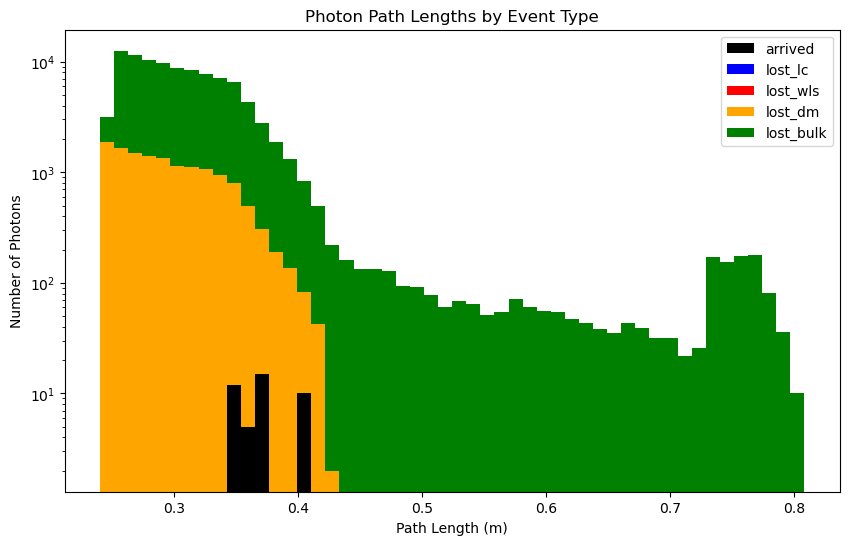

Overall detection efficiency: 0.42% (42 / 10000)


In [48]:
# stacked histgram of pathlengths by event type
plt.figure(figsize=(10, 6))
event_types = ['arrived', 'lost_lc', 'lost_wls', 'lost_dm', 'lost_bulk']
colors = ['k', 'blue', 'red', 'orange', 'green']
plt.hist(
    [simulation.data_df[simulation.data_df['event_type'] == et]['path_length'] for et in event_types],
    bins=50,
    stacked=True,
    color=colors,
    label=event_types,
)
plt.xlabel('Path Length (m)')
plt.ylabel('Number of Photons')
plt.yscale('log')
plt.title('Photon Path Lengths by Event Type')
plt.legend()
plt.show()

# print efficiency
n_arrived = int(simulation.data_df['arrived'].sum())
efficiency = n_arrived / simulation.num_photons * 100.0
print(f"Overall detection efficiency: {efficiency:.2f}% ({n_arrived} / {simulation.num_photons})")

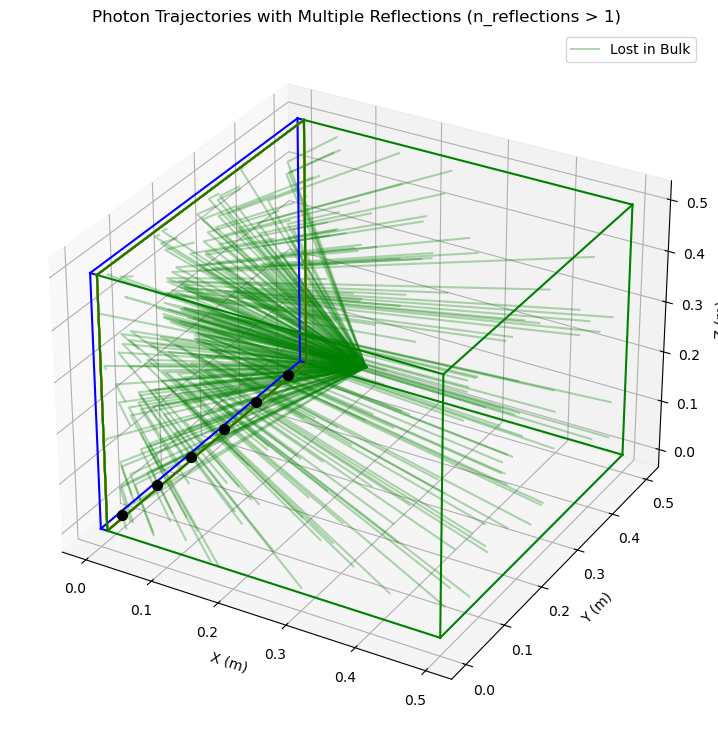

In [37]:
# Plot only trajectories with multiple reflections (n_reflections > 1)

plt.figure(figsize=(12, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

def plot_trajectories(df_subset, color, label, alpha=0.3, max_lines=200):
  for i, traj_str in enumerate(df_subset['trajectory']):
    if i >= max_lines:
      break
    points = np.array([list(map(float, p.split(','))) for p in traj_str.split(';')], dtype=float)
    ax.plot(points[:,0], points[:,1], points[:,2], color=color, alpha=alpha, label=label if i == 0 else None)

df_multi_refl = df[df['n_reflections'] > 0]
plot_trajectories(df_multi_refl, 'green', 'Lost in Bulk')

plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_dm'], 'orange', 'Lost in DM')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_wls'], 'red', 'Lost in WLS')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'lost_lc'], 'blue', 'Lost in LC')
plot_trajectories(df_multi_refl[df_multi_refl['event_type'] == 'arrived'], 'k', 'Arrived (Sensor)', alpha=0.7)

draw_box(lc_region_vertices, "blue")
draw_box(wls_region_vertices, "red")
draw_box(dm_region_vertices, "orange")
draw_box(bulk_region_vertices, "green")

for sp in sensor_positions:
  ax.scatter(sp[0], sp[1], sp[2], color="black", s=50)

ax.set_title('Photon Trajectories with Multiple Reflections (n_reflections > 1)')
ax.legend()
plt.show()


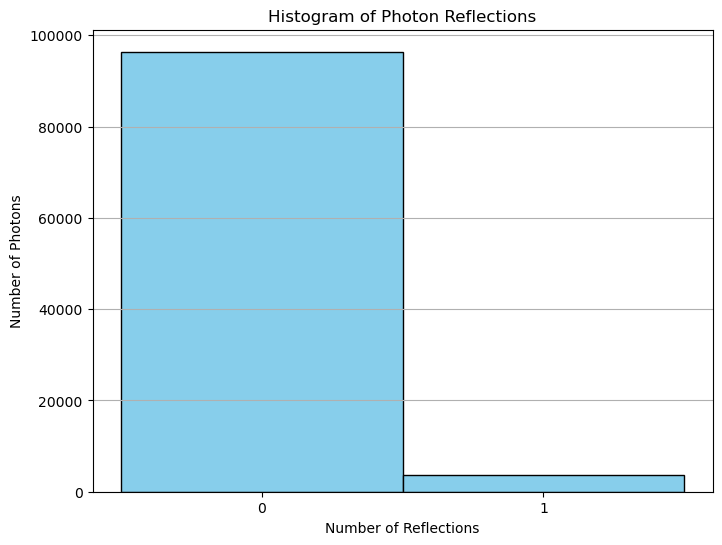

In [33]:
# make a histogram of  number of reflections
plt.figure(figsize=(8, 6))
plt.hist(df['n_reflections'], bins=range(0, df['n_reflections'].max()+2), align='left', color='skyblue', edgecolor='black')
plt.xlabel('Number of Reflections')
plt.ylabel('Number of Photons')
plt.title('Histogram of Photon Reflections')
plt.xticks(range(0, df['n_reflections'].max()+1))
plt.grid(axis='y')
plt.show()

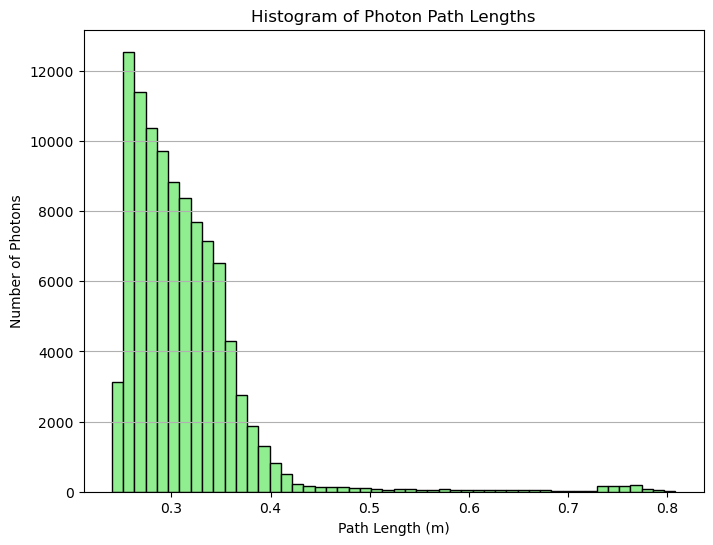

In [34]:
# make a histgoram of path lengths
plt.figure(figsize=(8, 6))
plt.hist(df['path_length'], bins=50, color='lightgreen', edgecolor='black')
plt.xlabel('Path Length (m)')
plt.ylabel('Number of Photons')
plt.title('Histogram of Photon Path Lengths')
plt.grid(axis='y')
plt.show()

In [41]:
#print(df["event_type"].value_counts().head(30))

#print(df[df["n_reflections"] > 0]["event_type"].value_counts())

print(pd.crosstab(df["event_type"], df["n_reflections"]))


n_reflections      0     1
event_type                
arrived           42     0
lost_bulk      82345  3609
lost_dm        14004     0
